# FER Experiments
### Datasets
- FER2013
- CK+
- AffectNet
- RF-DB

In [1]:
import random
import tensorflow as tf
import numpy as np

SEED = 7

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)


2026-01-20 23:55:49.320998: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import os, sys
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_rafbd, load_ck, load_fer2013, load_affectnet, load_meld, filter_emotions, load_iemocap
from src.evaluation import plot_confusion_matrix, plot_training_history
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
import cv2


def split_dataset_train_val_test(df, val_size=0.2, test_size=0.3, seed=SEED):
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=seed, stratify=df['label'])
    train_df, val_df = train_test_split(train_val_df, test_size=val_size/(1 - test_size), random_state=seed, stratify=train_val_df['label'])
    return train_df, val_df, test_df

def preprocess_fer_row(pixels_str, target_size=(48, 48)):
    # Convert string of space-separated pixel values to 2D image
    pixels = np.fromstring(pixels_str, sep=' ', dtype=np.uint8)
    pixels = pixels.reshape(target_size)
    # Convert to float, normalize, and expand dims
    pixels = pixels.astype("float32") / 255.0
    pixels = np.expand_dims(pixels, axis=-1)
    return pixels

def preprocess_raf_row(filename):
    # read and convert image to grayscale
    image = Image.open(filename).convert('L')
    image = image.resize((48, 48))
    np_image = np.array(image).astype("float32") / 255.0
    np_image = np.expand_dims(np_image, axis=-1)
    return np_image


ck = filter_emotions(load_ck())
fer = filter_emotions(load_fer2013())
raf = filter_emotions(load_rafbd())
affect = filter_emotions(load_affectnet())

ck["pixels"] = ck["pixels"].apply(preprocess_fer_row)
fer["pixels"] = fer["pixels"].apply(preprocess_fer_row)
raf["pixels"] = raf["filename"].apply(preprocess_raf_row)
affect["pixels"] = affect["filename"].apply(preprocess_raf_row)

cols = ['pixels', 'label']
ck, fer, raf, affect = ck[cols], fer[cols], raf[cols], affect[cols]


ck_train, ck_val, ck_test = split_dataset_train_val_test(ck)
raf_train, raf_val, raf_test = split_dataset_train_val_test(raf)
affect_train, affect_val, affect_test = split_dataset_train_val_test(affect)
fer_train, fer_val, fer_test = split_dataset_train_val_test(fer)

Subfolders in the dataset: ['ckextended.csv']
Subfolders in the dataset: ['fer2013.csv']


100%|██████████| 3068/3068 [00:02<00:00, 1341.97it/s]


Dataset downloaded to: /Users/sofiafernandes/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Available folders: ['happy', 'Contempt', 'sad', 'fear', 'surprise', 'neutral', 'Anger', 'disgust']


100%|██████████| 8/8 [00:13<00:00,  1.72s/it]


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from fer_cnn_utils import preprocess_frame, build_light_cnn
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam


def build_light_cnn(input_shape=(48, 48, 1), num_classes=7):
    """
    Lightweight CNN for emotion recognition from frames.
    """
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu', padding='same',),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dropout(0.7),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    
    

    optimizer = Adam(learning_rate=3e-4)
    model.compile(optimizer=optimizer, #'adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



# FER2013 + RAF-DB

Epoch 1/100
609/609 [==============================] - ETA: 0s - loss: 1.9797 - accuracy: 0.2673
Epoch 1: val_accuracy improved from -inf to 0.30352, saving model to best_cnn_model.h5
609/609 [==============================] - 75s 120ms/step - loss: 1.9797 - accuracy: 0.2673 - val_loss: 1.7181 - val_accuracy: 0.3035 - lr: 3.0000e-04
Epoch 2/100


/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


609/609 [==============================] - ETA: 0s - loss: 1.6239 - accuracy: 0.3586
Epoch 2: val_accuracy improved from 0.30352 to 0.39964, saving model to best_cnn_model.h5
609/609 [==============================] - 73s 119ms/step - loss: 1.6239 - accuracy: 0.3586 - val_loss: 1.5442 - val_accuracy: 0.3996 - lr: 3.0000e-04
Epoch 3/100
609/609 [==============================] - ETA: 0s - loss: 1.4980 - accuracy: 0.4148
Epoch 3: val_accuracy improved from 0.39964 to 0.46240, saving model to best_cnn_model.h5
609/609 [==============================] - 72s 118ms/step - loss: 1.4980 - accuracy: 0.4148 - val_loss: 1.4284 - val_accuracy: 0.4624 - lr: 3.0000e-04
Epoch 4/100
609/609 [==============================] - ETA: 0s - loss: 1.4015 - accuracy: 0.4591
Epoch 4: val_accuracy improved from 0.46240 to 0.46496, saving model to best_cnn_model.h5
609/609 [==============================] - 72s 118ms/step - loss: 1.4015 - accuracy: 0.4591 - val_loss: 1.3889 - val_accuracy: 0.4650 - lr: 3.0000e-0

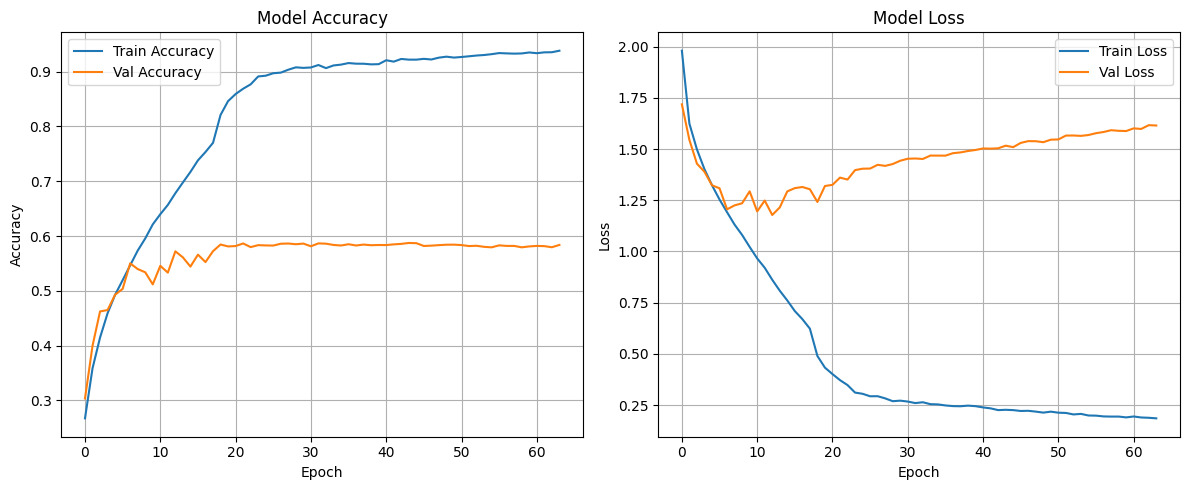

In [4]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, raf_train])
df_val = pd.concat([fer_val, raf_val])
df_test = ck
#df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 1s 34ms/step
              precision    recall  f1-score   support

       angry       0.19      0.36      0.25        45
     disgust       1.00      0.08      0.16        59
        fear       0.13      0.12      0.12        25
       happy       0.87      1.00      0.93        69
     neutral       0.92      0.90      0.91       593
         sad       0.21      0.46      0.29        28
    surprise       0.99      0.82      0.89        83

    accuracy                           0.78       902
   macro avg       0.62      0.53      0.51       902
weighted avg       0.85      0.78      0.79       902



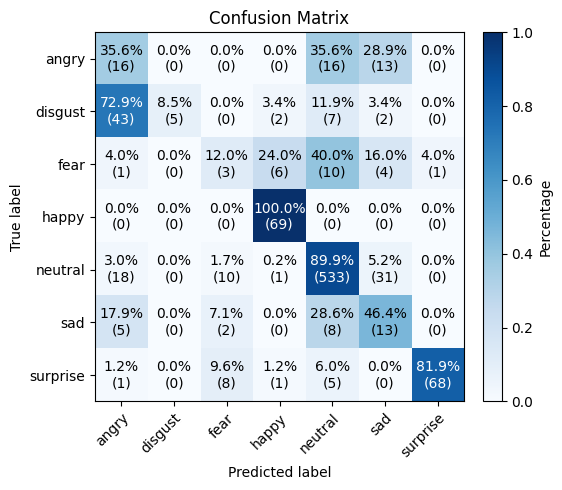

413/413 [==============================] - 15s 35ms/step
              precision    recall  f1-score   support

       angry       0.31      0.37      0.34      1718
     disgust       0.85      0.01      0.02      1248
        fear       0.30      0.28      0.29      1664
       happy       0.61      0.66      0.64      2704
     neutral       0.27      0.44      0.33      2368
         sad       0.23      0.30      0.26      1584
    surprise       0.48      0.17      0.25      1920

    accuracy                           0.36     13206
   macro avg       0.43      0.32      0.30     13206
weighted avg       0.43      0.36      0.34     13206



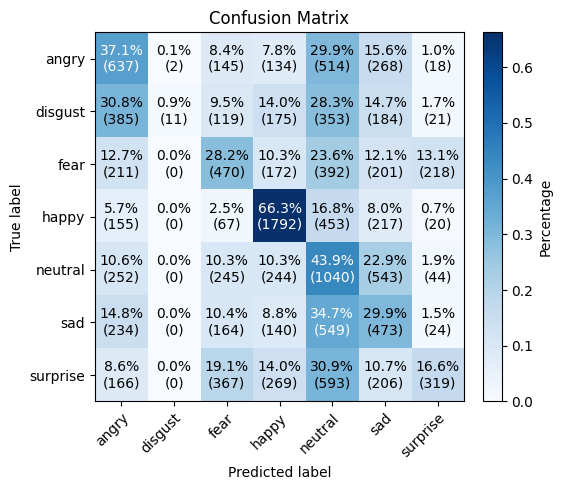

In [5]:
## CK
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## AffectNet
df_test = affect
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### FER2013, RAF-DB, AffectNet

Epoch 1/100
815/815 [==============================] - ETA: 0s - loss: 1.9803 - accuracy: 0.2539
Epoch 1: val_accuracy improved from -inf to 0.35356, saving model to best_cnn_model.h5
815/815 [==============================] - 100s 120ms/step - loss: 1.9803 - accuracy: 0.2539 - val_loss: 1.6759 - val_accuracy: 0.3536 - lr: 3.0000e-04
Epoch 2/100
  1/815 [..............................] - ETA: 1:27 - loss: 1.8516 - accuracy: 0.2188

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


815/815 [==============================] - ETA: 0s - loss: 1.6226 - accuracy: 0.3582
Epoch 2: val_accuracy improved from 0.35356 to 0.40243, saving model to best_cnn_model.h5
815/815 [==============================] - 96s 118ms/step - loss: 1.6226 - accuracy: 0.3582 - val_loss: 1.5290 - val_accuracy: 0.4024 - lr: 3.0000e-04
Epoch 3/100
815/815 [==============================] - ETA: 0s - loss: 1.4794 - accuracy: 0.4253
Epoch 3: val_accuracy improved from 0.40243 to 0.44441, saving model to best_cnn_model.h5
815/815 [==============================] - 99s 121ms/step - loss: 1.4794 - accuracy: 0.4253 - val_loss: 1.4474 - val_accuracy: 0.4444 - lr: 3.0000e-04
Epoch 4/100
815/815 [==============================] - ETA: 0s - loss: 1.3819 - accuracy: 0.4628
Epoch 4: val_accuracy improved from 0.44441 to 0.49348, saving model to best_cnn_model.h5
815/815 [==============================] - 95s 117ms/step - loss: 1.3819 - accuracy: 0.4628 - val_loss: 1.3235 - val_accuracy: 0.4935 - lr: 3.0000e-0

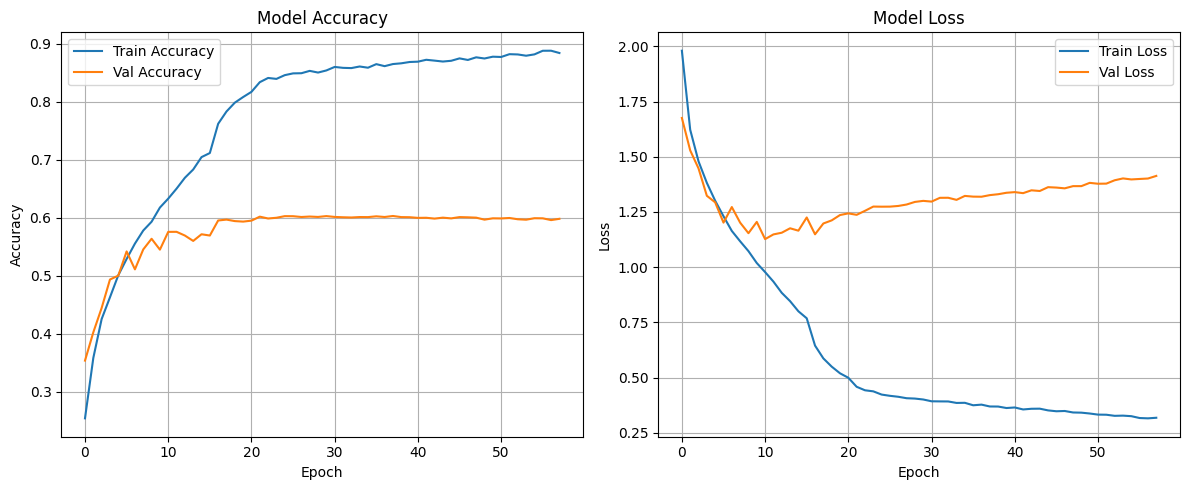

In [6]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, raf_train, affect_train])
df_val = pd.concat([fer_val, raf_val, affect_val])
df_test = ck
#df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 1s 31ms/step
              precision    recall  f1-score   support

       angry       0.25      0.47      0.33        45
     disgust       1.00      0.19      0.31        59
        fear       0.26      0.24      0.25        25
       happy       0.85      1.00      0.92        69
     neutral       0.94      0.84      0.89       593
         sad       0.16      0.50      0.24        28
    surprise       0.90      0.90      0.90        83

    accuracy                           0.77       902
   macro avg       0.62      0.59      0.55       902
weighted avg       0.86      0.77      0.79       902



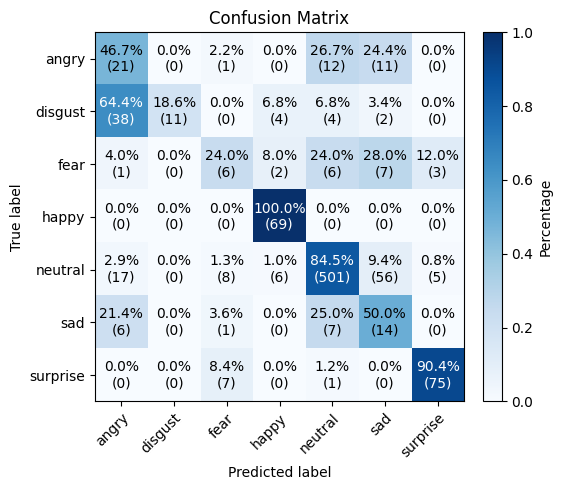

In [7]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### FER2013, AffectNet

Epoch 1/100
767/767 [==============================] - ETA: 0s - loss: 1.9637 - accuracy: 0.2627
Epoch 1: val_accuracy improved from -inf to 0.31568, saving model to best_cnn_model.h5
767/767 [==============================] - 91s 115ms/step - loss: 1.9637 - accuracy: 0.2627 - val_loss: 1.7030 - val_accuracy: 0.3157 - lr: 3.0000e-04
Epoch 2/100
  1/767 [..............................] - ETA: 1:32 - loss: 1.5250 - accuracy: 0.5000

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


767/767 [==============================] - ETA: 0s - loss: 1.6271 - accuracy: 0.3671
Epoch 2: val_accuracy improved from 0.31568 to 0.42994, saving model to best_cnn_model.h5
767/767 [==============================] - 88s 115ms/step - loss: 1.6271 - accuracy: 0.3671 - val_loss: 1.4839 - val_accuracy: 0.4299 - lr: 3.0000e-04
Epoch 3/100
767/767 [==============================] - ETA: 0s - loss: 1.4731 - accuracy: 0.4302
Epoch 3: val_accuracy improved from 0.42994 to 0.44358, saving model to best_cnn_model.h5
767/767 [==============================] - 88s 114ms/step - loss: 1.4731 - accuracy: 0.4302 - val_loss: 1.4437 - val_accuracy: 0.4436 - lr: 3.0000e-04
Epoch 4/100
767/767 [==============================] - ETA: 0s - loss: 1.3637 - accuracy: 0.4721
Epoch 4: val_accuracy improved from 0.44358 to 0.48422, saving model to best_cnn_model.h5
767/767 [==============================] - 88s 115ms/step - loss: 1.3637 - accuracy: 0.4721 - val_loss: 1.3271 - val_accuracy: 0.4842 - lr: 3.0000e-0

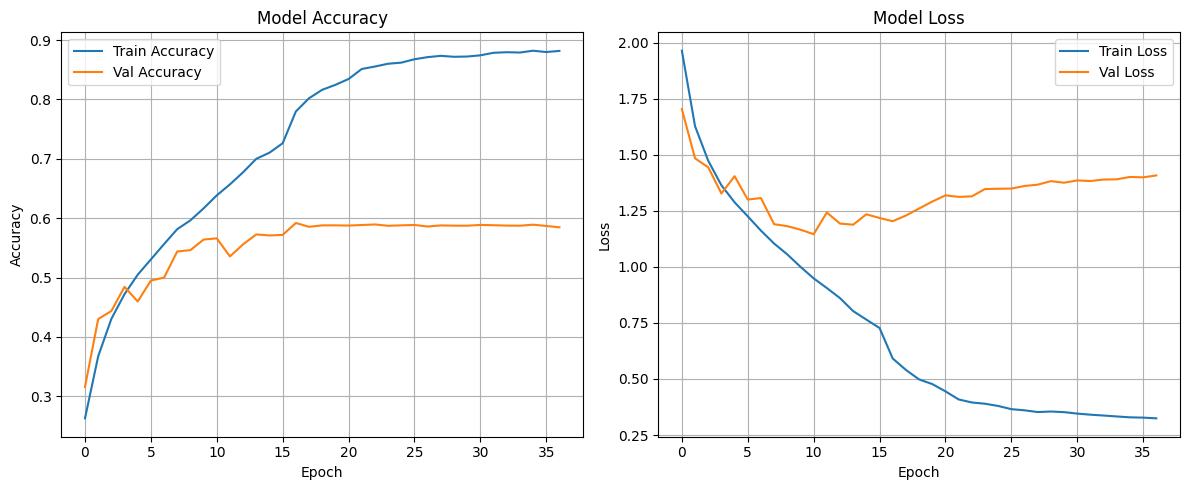

In [8]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, affect_train])
df_val = pd.concat([fer_val, affect_val])
df_test = ck
#df_test = raf

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 1s 32ms/step
              precision    recall  f1-score   support

       angry       0.17      0.33      0.23        45
     disgust       0.75      0.05      0.10        59
        fear       0.20      0.16      0.18        25
       happy       0.91      1.00      0.95        69
     neutral       0.91      0.90      0.90       593
         sad       0.19      0.29      0.23        28
    surprise       0.88      0.93      0.90        83

    accuracy                           0.78       902
   macro avg       0.57      0.52      0.50       902
weighted avg       0.82      0.78      0.78       902



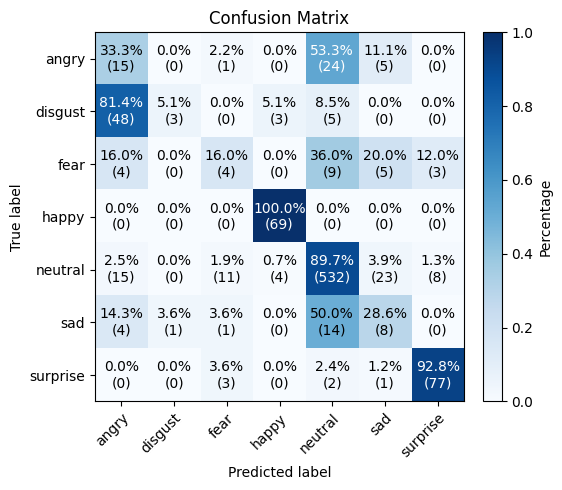

96/96 [==============================] - 3s 33ms/step
              precision    recall  f1-score   support

       angry       0.27      0.59      0.37       162
     disgust       0.36      0.03      0.06       160
        fear       0.08      0.14      0.10        74
       happy       0.78      0.82      0.80      1185
     neutral       0.55      0.50      0.52       680
         sad       0.41      0.54      0.47       478
    surprise       0.95      0.18      0.31       329

    accuracy                           0.57      3068
   macro avg       0.48      0.40      0.37      3068
weighted avg       0.62      0.57      0.56      3068



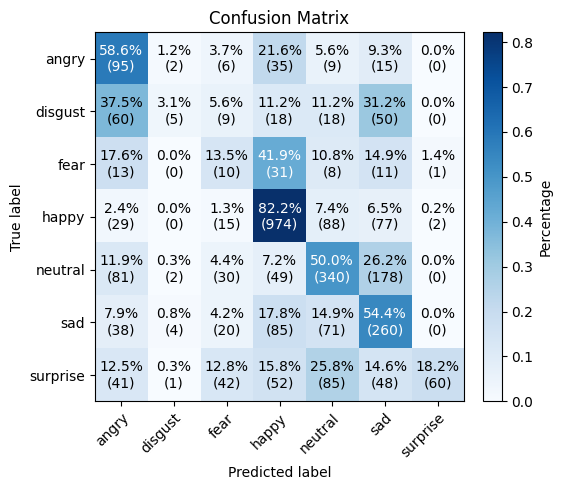

In [9]:
## CK
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## RAF
df_test = raf
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### RAF-DB, AffectNet

Epoch 1/100
254/255 [============================>.] - ETA: 0s - loss: 2.2620 - accuracy: 0.2367
Epoch 1: val_accuracy improved from -inf to 0.23894, saving model to best_cnn_model.h5
255/255 [==============================] - 32s 117ms/step - loss: 2.2617 - accuracy: 0.2366 - val_loss: 4.2598 - val_accuracy: 0.2389 - lr: 3.0000e-04
Epoch 2/100


/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


254/255 [============================>.] - ETA: 0s - loss: 1.5911 - accuracy: 0.3279
Epoch 2: val_accuracy improved from 0.23894 to 0.36794, saving model to best_cnn_model.h5
255/255 [==============================] - 29s 113ms/step - loss: 1.5908 - accuracy: 0.3278 - val_loss: 1.5480 - val_accuracy: 0.3679 - lr: 3.0000e-04
Epoch 3/100
254/255 [============================>.] - ETA: 0s - loss: 1.4551 - accuracy: 0.3645
Epoch 3: val_accuracy improved from 0.36794 to 0.39312, saving model to best_cnn_model.h5
255/255 [==============================] - 30s 117ms/step - loss: 1.4549 - accuracy: 0.3647 - val_loss: 1.3820 - val_accuracy: 0.3931 - lr: 3.0000e-04
Epoch 4/100
254/255 [============================>.] - ETA: 0s - loss: 1.3873 - accuracy: 0.4012
Epoch 4: val_accuracy improved from 0.39312 to 0.45424, saving model to best_cnn_model.h5
255/255 [==============================] - 29s 114ms/step - loss: 1.3872 - accuracy: 0.4011 - val_loss: 1.3270 - val_accuracy: 0.4542 - lr: 3.0000e-0

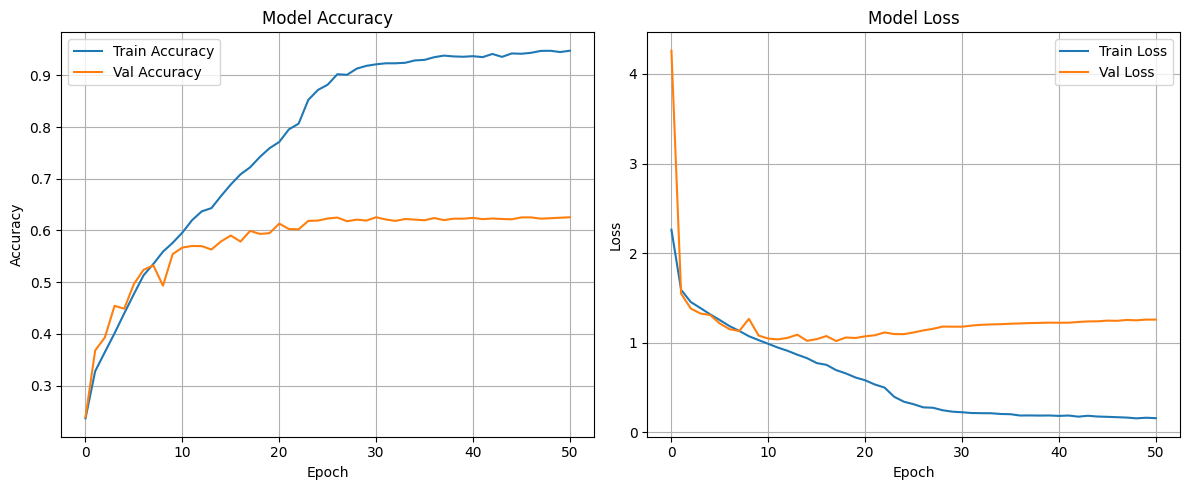

In [10]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([raf_train, affect_train])
df_val = pd.concat([raf_val, affect_val])
df_test = ck
#df_test = fer

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 1s 30ms/step
              precision    recall  f1-score   support

       angry       0.13      0.38      0.20        45
     disgust       0.26      0.69      0.38        59
        fear       0.05      0.72      0.09        25
       happy       1.00      0.03      0.06        69
     neutral       0.00      0.00      0.00       593
         sad       0.07      0.43      0.12        28
    surprise       0.20      0.16      0.18        83

    accuracy                           0.11       902
   macro avg       0.24      0.34      0.14       902
weighted avg       0.12      0.11      0.06       902



/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

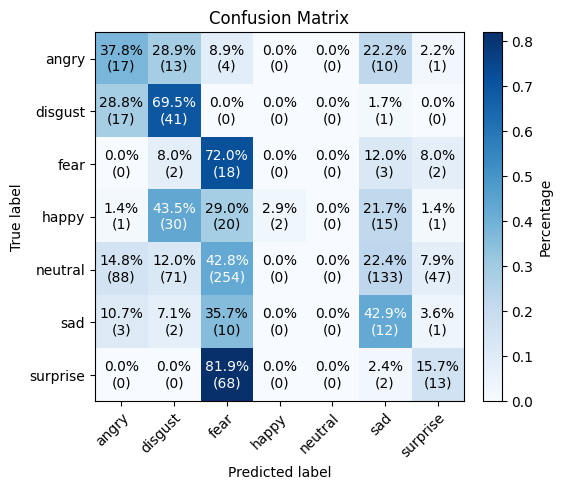

1122/1122 [==============================] - 33s 29ms/step
              precision    recall  f1-score   support

       angry       0.34      0.29      0.31      4953
     disgust       0.03      0.25      0.05       547
        fear       0.20      0.23      0.21      5121
       happy       0.62      0.21      0.31      8989
     neutral       0.23      0.12      0.16      6198
         sad       0.26      0.34      0.29      6077
    surprise       0.25      0.42      0.31      4002

    accuracy                           0.25     35887
   macro avg       0.27      0.27      0.24     35887
weighted avg       0.34      0.25      0.26     35887



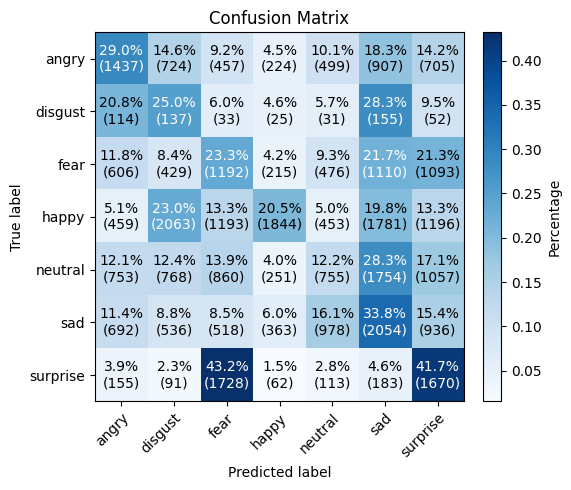

In [11]:
## CK
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## FER
df_test = fer
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### CK, RAF-DB

Epoch 1/100
62/62 [==============================] - ETA: 0s - loss: 2.6201 - accuracy: 0.3253
Epoch 1: val_accuracy improved from -inf to 0.31069, saving model to best_cnn_model.h5
62/62 [==============================] - 9s 120ms/step - loss: 2.6201 - accuracy: 0.3253 - val_loss: 1.9790 - val_accuracy: 0.3107 - lr: 3.0000e-04
Epoch 2/100
 1/62 [..............................] - ETA: 8s - loss: 1.7762 - accuracy: 0.4375

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


62/62 [==============================] - ETA: 0s - loss: 1.8434 - accuracy: 0.4070
Epoch 2: val_accuracy improved from 0.31069 to 0.31572, saving model to best_cnn_model.h5
62/62 [==============================] - 7s 113ms/step - loss: 1.8434 - accuracy: 0.4070 - val_loss: 2.3194 - val_accuracy: 0.3157 - lr: 3.0000e-04
Epoch 3/100
62/62 [==============================] - ETA: 0s - loss: 1.5796 - accuracy: 0.4559
Epoch 3: val_accuracy did not improve from 0.31572
62/62 [==============================] - 7s 110ms/step - loss: 1.5796 - accuracy: 0.4559 - val_loss: 2.7954 - val_accuracy: 0.3157 - lr: 3.0000e-04
Epoch 4/100
62/62 [==============================] - ETA: 0s - loss: 1.4794 - accuracy: 0.4846
Epoch 4: val_accuracy did not improve from 0.31572
62/62 [==============================] - 7s 112ms/step - loss: 1.4794 - accuracy: 0.4846 - val_loss: 2.6977 - val_accuracy: 0.3157 - lr: 3.0000e-04
Epoch 5/100
62/62 [==============================] - ETA: 0s - loss: 1.3454 - accuracy: 0.5

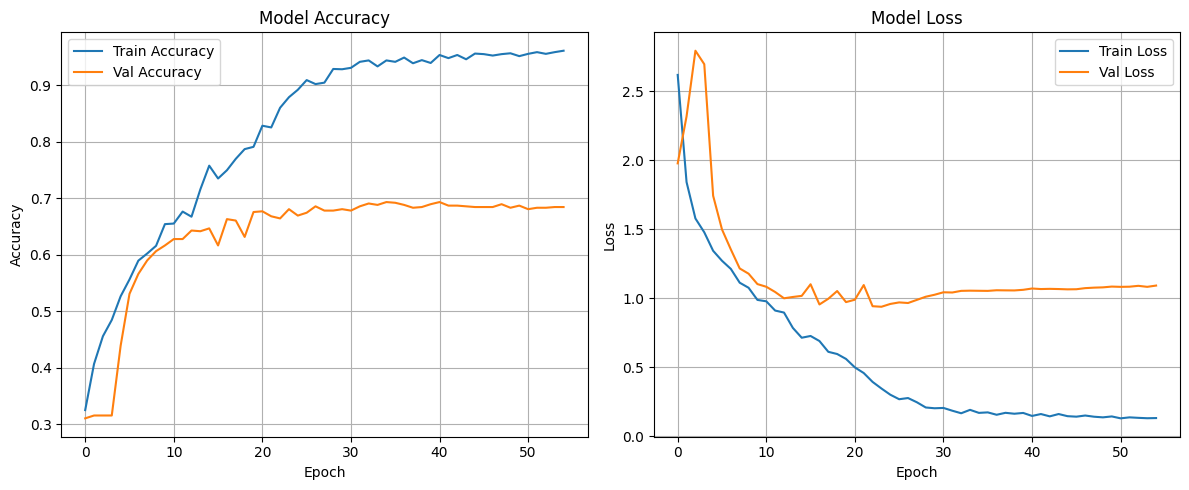

In [12]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([raf_train, ck_train])
df_val = pd.concat([raf_val, ck_val])
df_test = affect
#df_test = fer

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

413/413 [==============================] - 13s 31ms/step
              precision    recall  f1-score   support

       angry       0.32      0.20      0.25      1718
     disgust       0.18      0.11      0.13      1248
        fear       0.16      0.07      0.10      1664
       happy       0.36      0.21      0.27      2704
     neutral       0.19      0.31      0.23      2368
         sad       0.11      0.19      0.14      1584
    surprise       0.23      0.30      0.26      1920

    accuracy                           0.21     13206
   macro avg       0.22      0.20      0.20     13206
weighted avg       0.23      0.21      0.21     13206



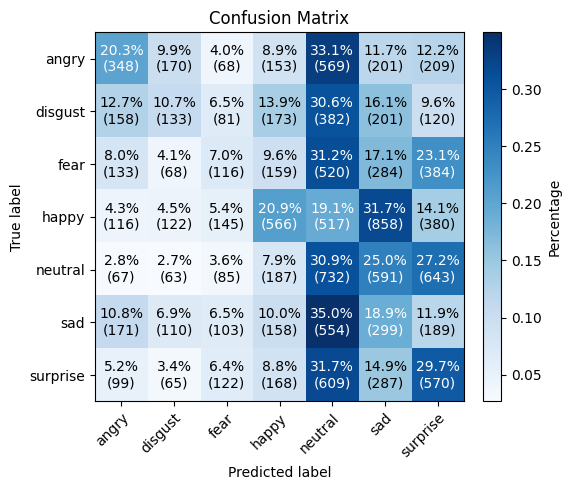

1122/1122 [==============================] - 35s 31ms/step
              precision    recall  f1-score   support

       angry       0.29      0.15      0.20      4953
     disgust       0.04      0.09      0.06       547
        fear       0.18      0.04      0.06      5121
       happy       0.61      0.51      0.55      8989
     neutral       0.29      0.56      0.38      6198
         sad       0.25      0.21      0.23      6077
    surprise       0.34      0.55      0.42      4002

    accuracy                           0.35     35887
   macro avg       0.29      0.30      0.27     35887
weighted avg       0.35      0.35      0.33     35887



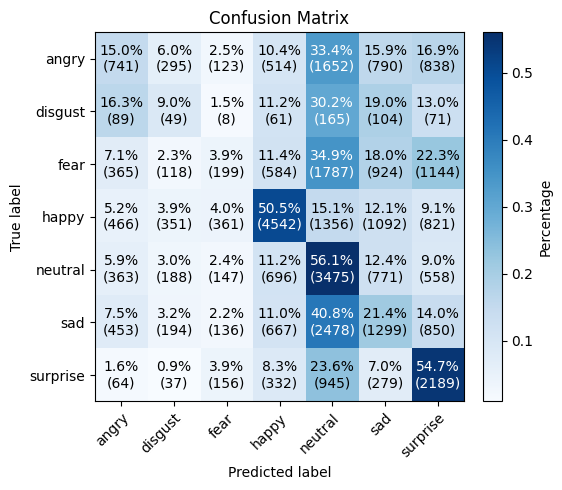

In [13]:
## AN
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## FER
df_test = fer
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### CK, RAF-DB, AffectNet

Epoch 1/100
269/269 [==============================] - ETA: 0s - loss: 2.2017 - accuracy: 0.2284
Epoch 1: val_accuracy improved from -inf to 0.23160, saving model to best_cnn_model.h5
269/269 [==============================] - 32s 109ms/step - loss: 2.2017 - accuracy: 0.2284 - val_loss: 3.3537 - val_accuracy: 0.2316 - lr: 3.0000e-04
Epoch 2/100
  1/269 [..............................] - ETA: 28s - loss: 1.8305 - accuracy: 0.2500

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


268/269 [============================>.] - ETA: 0s - loss: 1.6115 - accuracy: 0.3391
Epoch 2: val_accuracy improved from 0.23160 to 0.33983, saving model to best_cnn_model.h5
269/269 [==============================] - 29s 110ms/step - loss: 1.6112 - accuracy: 0.3393 - val_loss: 1.6237 - val_accuracy: 0.3398 - lr: 3.0000e-04
Epoch 3/100
268/269 [============================>.] - ETA: 0s - loss: 1.4451 - accuracy: 0.3905
Epoch 3: val_accuracy improved from 0.33983 to 0.45854, saving model to best_cnn_model.h5
269/269 [==============================] - 29s 110ms/step - loss: 1.4455 - accuracy: 0.3904 - val_loss: 1.3481 - val_accuracy: 0.4585 - lr: 3.0000e-04
Epoch 4/100
268/269 [============================>.] - ETA: 0s - loss: 1.3386 - accuracy: 0.4517
Epoch 4: val_accuracy improved from 0.45854 to 0.49200, saving model to best_cnn_model.h5
269/269 [==============================] - 30s 110ms/step - loss: 1.3391 - accuracy: 0.4517 - val_loss: 1.2545 - val_accuracy: 0.4920 - lr: 3.0000e-0

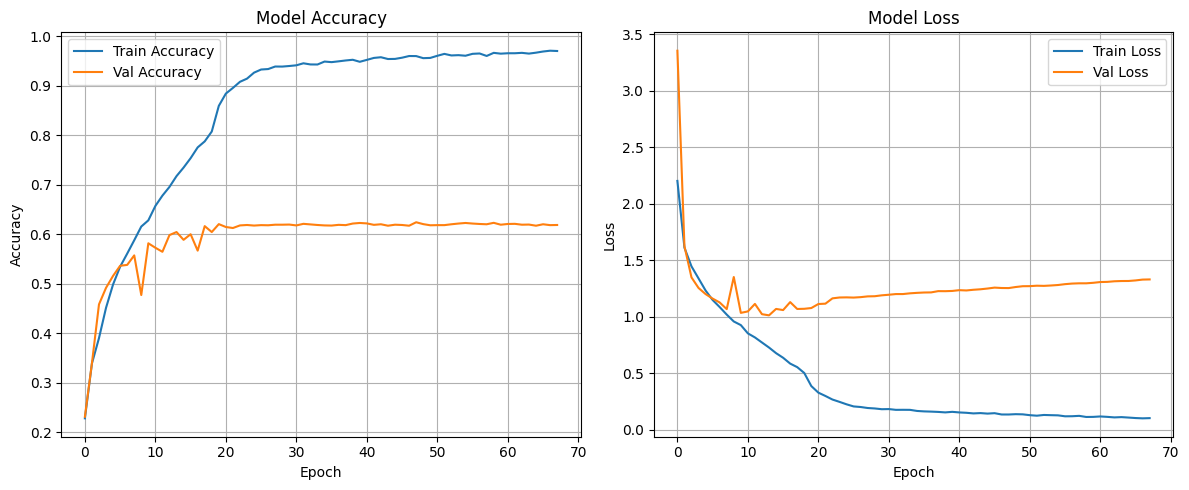

In [14]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([ck_train, raf_train, affect_train])
df_val = pd.concat([ck_val, raf_val, affect_val])
df_test = fer
#df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

1122/1122 [==============================] - 35s 31ms/step
              precision    recall  f1-score   support

       angry       0.33      0.32      0.32      4953
     disgust       0.04      0.24      0.06       547
        fear       0.22      0.22      0.22      5121
       happy       0.67      0.27      0.38      8989
     neutral       0.30      0.16      0.21      6198
         sad       0.25      0.32      0.28      6077
    surprise       0.27      0.53      0.36      4002

    accuracy                           0.29     35887
   macro avg       0.30      0.29      0.26     35887
weighted avg       0.37      0.29      0.30     35887



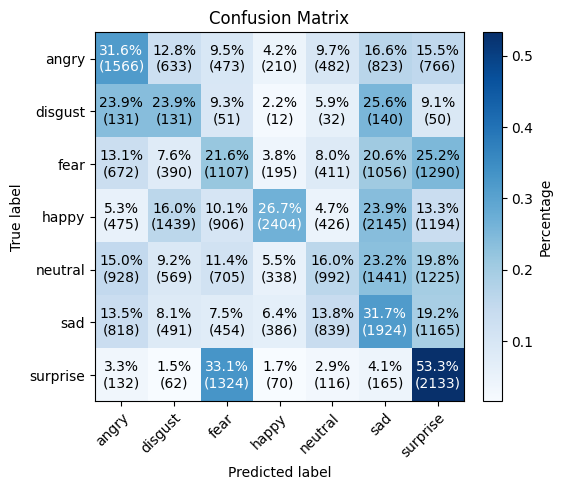

In [15]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### CK, AffectNet

Epoch 1/100
221/221 [==============================] - ETA: 0s - loss: 2.3122 - accuracy: 0.2354
Epoch 1: val_accuracy improved from -inf to 0.11725, saving model to best_cnn_model.h5
221/221 [==============================] - 27s 115ms/step - loss: 2.3122 - accuracy: 0.2354 - val_loss: 3.4852 - val_accuracy: 0.1173 - lr: 3.0000e-04
Epoch 2/100
  1/221 [..............................] - ETA: 22s - loss: 1.6100 - accuracy: 0.4062

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


220/221 [============================>.] - ETA: 0s - loss: 1.6059 - accuracy: 0.3359
Epoch 2: val_accuracy improved from 0.11725 to 0.32908, saving model to best_cnn_model.h5
221/221 [==============================] - 25s 111ms/step - loss: 1.6061 - accuracy: 0.3356 - val_loss: 1.8262 - val_accuracy: 0.3291 - lr: 3.0000e-04
Epoch 3/100
220/221 [============================>.] - ETA: 0s - loss: 1.4287 - accuracy: 0.3999
Epoch 3: val_accuracy improved from 0.32908 to 0.44492, saving model to best_cnn_model.h5
221/221 [==============================] - 25s 112ms/step - loss: 1.4283 - accuracy: 0.4000 - val_loss: 1.3355 - val_accuracy: 0.4449 - lr: 3.0000e-04
Epoch 4/100
221/221 [==============================] - ETA: 0s - loss: 1.3027 - accuracy: 0.4412
Epoch 4: val_accuracy improved from 0.44492 to 0.46405, saving model to best_cnn_model.h5
221/221 [==============================] - 25s 113ms/step - loss: 1.3027 - accuracy: 0.4412 - val_loss: 1.2534 - val_accuracy: 0.4640 - lr: 3.0000e-0

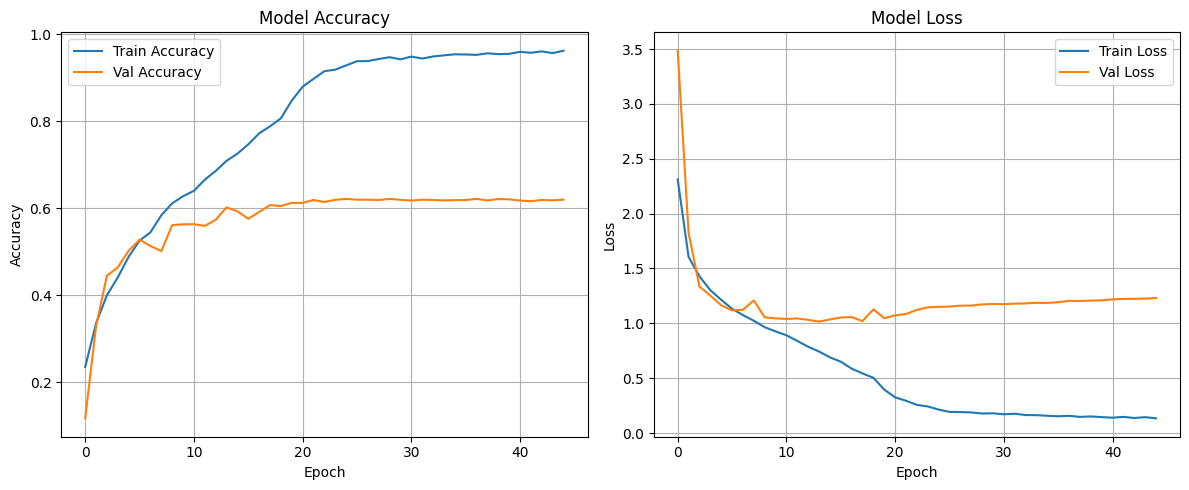

In [16]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([ck_train, affect_train])
df_val = pd.concat([ck_val, affect_val])
df_test = fer
#df_test = raf

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

1122/1122 [==============================] - 35s 31ms/step
              precision    recall  f1-score   support

       angry       0.26      0.34      0.30      4953
     disgust       0.03      0.36      0.05       547
        fear       0.21      0.21      0.21      5121
       happy       0.57      0.08      0.14      8989
     neutral       0.26      0.08      0.12      6198
         sad       0.26      0.27      0.26      6077
    surprise       0.24      0.46      0.31      4002

    accuracy                           0.21     35887
   macro avg       0.26      0.26      0.20     35887
weighted avg       0.32      0.21      0.21     35887



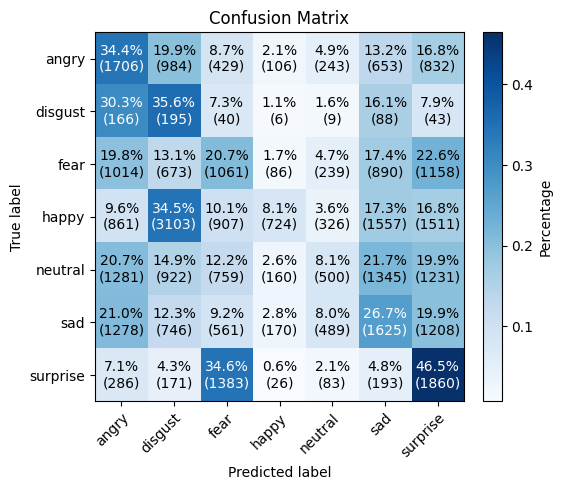

96/96 [==============================] - 3s 31ms/step
              precision    recall  f1-score   support

       angry       0.11      0.37      0.17       162
     disgust       0.08      0.54      0.13       160
        fear       0.05      0.09      0.07        74
       happy       0.72      0.06      0.11      1185
     neutral       0.46      0.03      0.06       680
         sad       0.20      0.36      0.26       478
    surprise       0.33      0.28      0.30       329

    accuracy                           0.17      3068
   macro avg       0.28      0.25      0.16      3068
weighted avg       0.46      0.17      0.15      3068



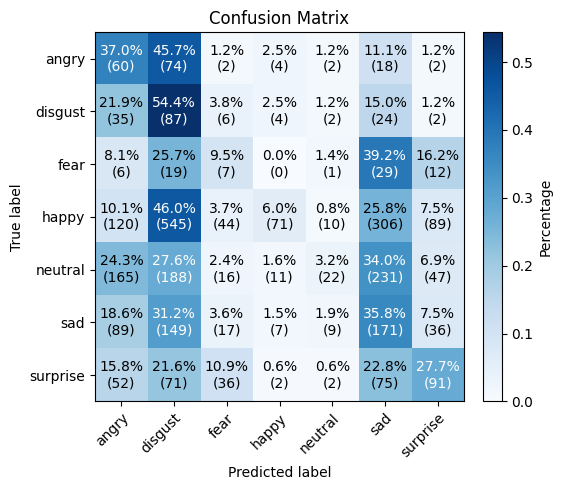

In [17]:
## FER
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## RAF
df_test = raf
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### FER2012, CK, AffectNet

Epoch 1/100
781/782 [============================>.] - ETA: 0s - loss: 1.9982 - accuracy: 0.2396
Epoch 1: val_accuracy improved from -inf to 0.30867, saving model to best_cnn_model.h5
782/782 [==============================] - 90s 113ms/step - loss: 1.9982 - accuracy: 0.2397 - val_loss: 1.7245 - val_accuracy: 0.3087 - lr: 3.0000e-04
Epoch 2/100


/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


781/782 [============================>.] - ETA: 0s - loss: 1.6531 - accuracy: 0.3529
Epoch 2: val_accuracy improved from 0.30867 to 0.41246, saving model to best_cnn_model.h5
782/782 [==============================] - 88s 112ms/step - loss: 1.6531 - accuracy: 0.3529 - val_loss: 1.5546 - val_accuracy: 0.4125 - lr: 3.0000e-04
Epoch 3/100
781/782 [============================>.] - ETA: 0s - loss: 1.4912 - accuracy: 0.4254
Epoch 3: val_accuracy improved from 0.41246 to 0.46795, saving model to best_cnn_model.h5
782/782 [==============================] - 88s 113ms/step - loss: 1.4912 - accuracy: 0.4253 - val_loss: 1.3930 - val_accuracy: 0.4680 - lr: 3.0000e-04
Epoch 4/100
781/782 [============================>.] - ETA: 0s - loss: 1.3677 - accuracy: 0.4760
Epoch 4: val_accuracy improved from 0.46795 to 0.48485, saving model to best_cnn_model.h5
782/782 [==============================] - 89s 114ms/step - loss: 1.3677 - accuracy: 0.4760 - val_loss: 1.3153 - val_accuracy: 0.4849 - lr: 3.0000e-0

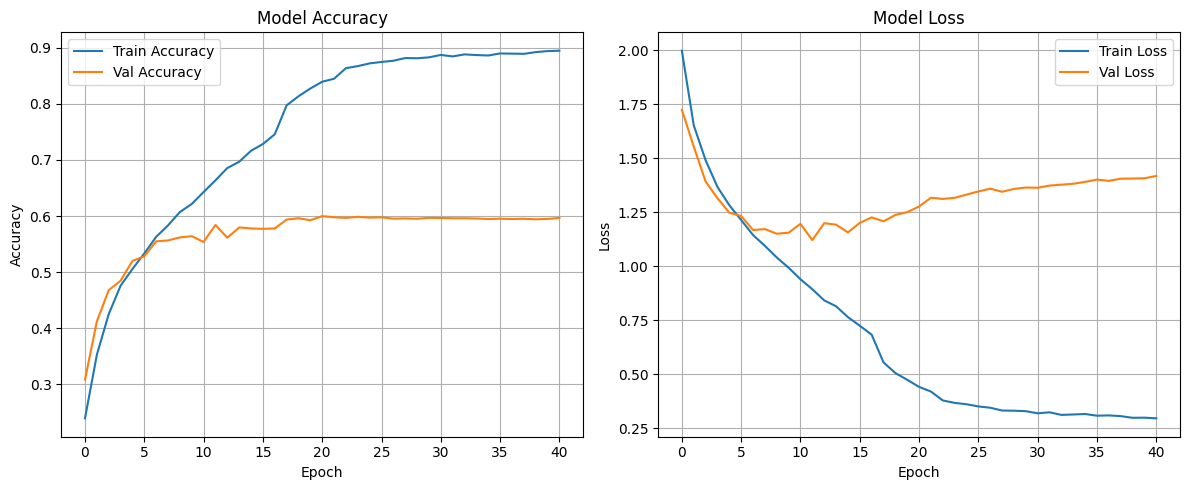

In [18]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, ck_train, affect_train])
df_val = pd.concat([fer_val, ck_val, affect_val])
#df_test = fer
df_test = raf

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

96/96 [==============================] - 3s 30ms/step
              precision    recall  f1-score   support

       angry       0.24      0.54      0.34       162
     disgust       0.26      0.04      0.07       160
        fear       0.08      0.12      0.10        74
       happy       0.78      0.82      0.80      1185
     neutral       0.55      0.47      0.51       680
         sad       0.38      0.57      0.46       478
    surprise       0.95      0.16      0.27       329

    accuracy                           0.56      3068
   macro avg       0.47      0.39      0.36      3068
weighted avg       0.62      0.56      0.55      3068



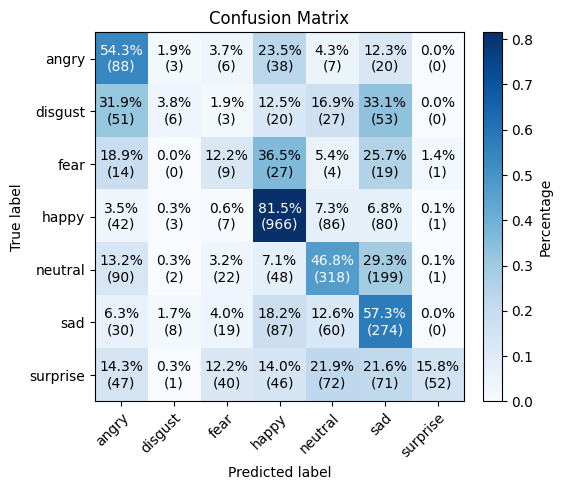

In [19]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### CK, FER2013

Epoch 1/100
575/575 [==============================] - ETA: 0s - loss: 2.0392 - accuracy: 0.2530
Epoch 1: val_accuracy improved from -inf to 0.33578, saving model to best_cnn_model.h5
575/575 [==============================] - 65s 109ms/step - loss: 2.0392 - accuracy: 0.2530 - val_loss: 1.7073 - val_accuracy: 0.3358 - lr: 3.0000e-04
Epoch 2/100
  1/575 [..............................] - ETA: 56s - loss: 1.7950 - accuracy: 0.3750

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


575/575 [==============================] - ETA: 0s - loss: 1.6357 - accuracy: 0.3606
Epoch 2: val_accuracy improved from 0.33578 to 0.42818, saving model to best_cnn_model.h5
575/575 [==============================] - 62s 108ms/step - loss: 1.6357 - accuracy: 0.3606 - val_loss: 1.4967 - val_accuracy: 0.4282 - lr: 3.0000e-04
Epoch 3/100
575/575 [==============================] - ETA: 0s - loss: 1.4920 - accuracy: 0.4251
Epoch 3: val_accuracy improved from 0.42818 to 0.43905, saving model to best_cnn_model.h5
575/575 [==============================] - 62s 108ms/step - loss: 1.4920 - accuracy: 0.4251 - val_loss: 1.4905 - val_accuracy: 0.4391 - lr: 3.0000e-04
Epoch 4/100
575/575 [==============================] - ETA: 0s - loss: 1.4035 - accuracy: 0.4642
Epoch 4: val_accuracy improved from 0.43905 to 0.44327, saving model to best_cnn_model.h5
575/575 [==============================] - 62s 107ms/step - loss: 1.4035 - accuracy: 0.4642 - val_loss: 1.4599 - val_accuracy: 0.4433 - lr: 3.0000e-0

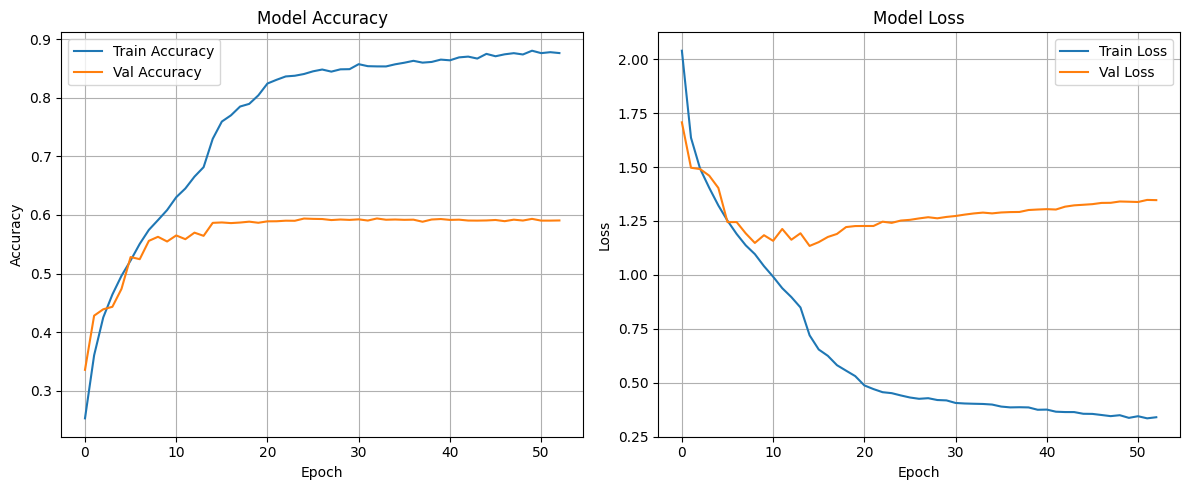

In [20]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, ck_train])
df_val = pd.concat([fer_val, ck_val])

#df_test = raf
df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

413/413 [==============================] - 13s 31ms/step
              precision    recall  f1-score   support

       angry       0.30      0.39      0.34      1718
     disgust       0.83      0.00      0.01      1248
        fear       0.37      0.19      0.25      1664
       happy       0.61      0.64      0.63      2704
     neutral       0.25      0.45      0.32      2368
         sad       0.22      0.32      0.26      1584
    surprise       0.45      0.16      0.24      1920

    accuracy                           0.35     13206
   macro avg       0.43      0.31      0.29     13206
weighted avg       0.43      0.35      0.33     13206



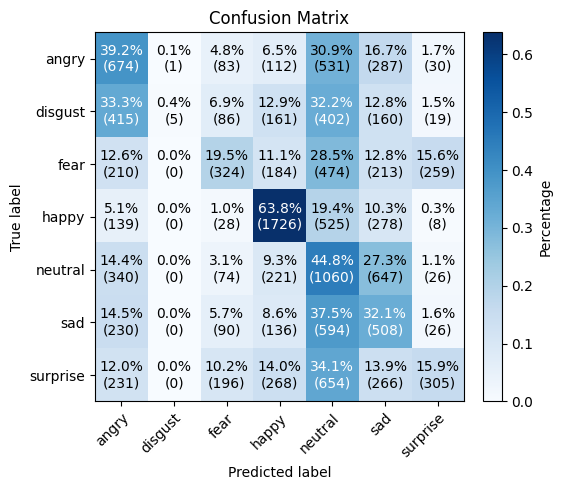

96/96 [==============================] - 3s 31ms/step
              precision    recall  f1-score   support

       angry       0.26      0.61      0.36       162
     disgust       0.33      0.02      0.04       160
        fear       0.08      0.11      0.09        74
       happy       0.80      0.79      0.79      1185
     neutral       0.52      0.48      0.50       680
         sad       0.35      0.54      0.43       478
    surprise       0.96      0.14      0.25       329

    accuracy                           0.55      3068
   macro avg       0.47      0.38      0.35      3068
weighted avg       0.61      0.55      0.53      3068



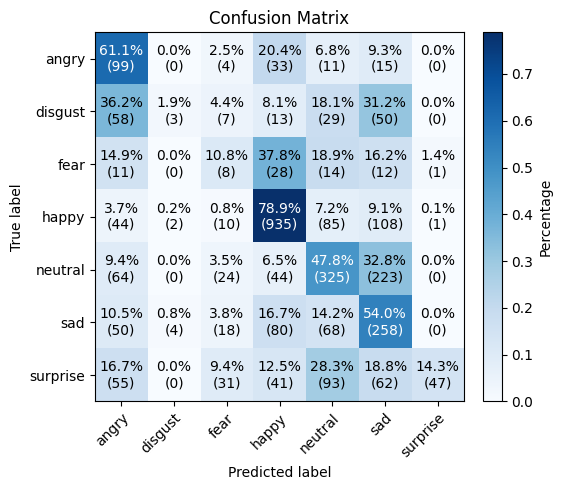

In [21]:
## AN
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## RAF
df_test = raf
X_test  = np.stack(df_test["pixels"].values)
y_test = label_encoder.transform(df_test['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)


### FER2013, RAF-DB, CK+

Epoch 1/100
623/623 [==============================] - ETA: 0s - loss: 1.9811 - accuracy: 0.2759
Epoch 1: val_accuracy improved from -inf to 0.33839, saving model to best_cnn_model.h5
623/623 [==============================] - 73s 113ms/step - loss: 1.9811 - accuracy: 0.2759 - val_loss: 1.6625 - val_accuracy: 0.3384 - lr: 3.0000e-04
Epoch 2/100


/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


623/623 [==============================] - ETA: 0s - loss: 1.5989 - accuracy: 0.3892
Epoch 2: val_accuracy improved from 0.33839 to 0.43334, saving model to best_cnn_model.h5
623/623 [==============================] - 70s 113ms/step - loss: 1.5989 - accuracy: 0.3892 - val_loss: 1.4754 - val_accuracy: 0.4333 - lr: 3.0000e-04
Epoch 3/100
623/623 [==============================] - ETA: 0s - loss: 1.4710 - accuracy: 0.4376
Epoch 3: val_accuracy improved from 0.43334 to 0.47172, saving model to best_cnn_model.h5
623/623 [==============================] - 70s 113ms/step - loss: 1.4710 - accuracy: 0.4376 - val_loss: 1.3721 - val_accuracy: 0.4717 - lr: 3.0000e-04
Epoch 4/100
623/623 [==============================] - ETA: 0s - loss: 1.3789 - accuracy: 0.4728
Epoch 4: val_accuracy improved from 0.47172 to 0.50044, saving model to best_cnn_model.h5
623/623 [==============================] - 70s 112ms/step - loss: 1.3789 - accuracy: 0.4728 - val_loss: 1.3362 - val_accuracy: 0.5004 - lr: 3.0000e-0

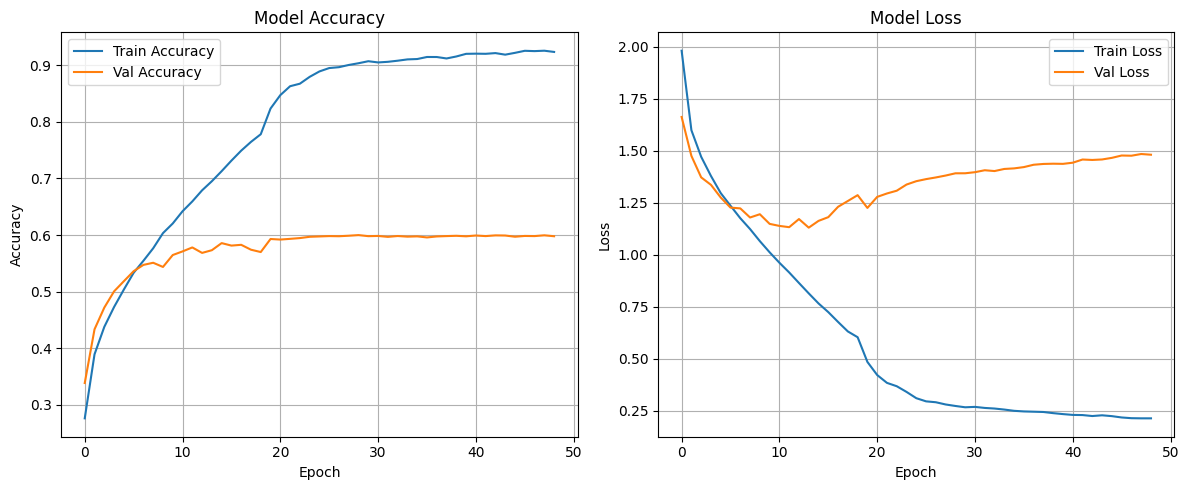

In [22]:

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

df_train = pd.concat([fer_train, ck_train, raf_train])
df_val = pd.concat([fer_val, ck_val, raf_val])

#df_test = raf
df_test = affect

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(df_train['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(df_train["pixels"].values)
X_val   = np.stack(df_val["pixels"].values)
X_test  = np.stack(df_test["pixels"].values)

y_train = label_encoder.transform(df_train['label'].values)
y_val = label_encoder.transform(df_val['label'].values)
y_test = label_encoder.transform(df_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

413/413 [==============================] - 13s 31ms/step
              precision    recall  f1-score   support

       angry       0.30      0.40      0.34      1718
     disgust       0.50      0.00      0.01      1248
        fear       0.32      0.19      0.24      1664
       happy       0.60      0.63      0.61      2704
     neutral       0.25      0.42      0.32      2368
         sad       0.20      0.31      0.24      1584
    surprise       0.45      0.14      0.22      1920

    accuracy                           0.34     13206
   macro avg       0.38      0.30      0.28     13206
weighted avg       0.38      0.34      0.32     13206



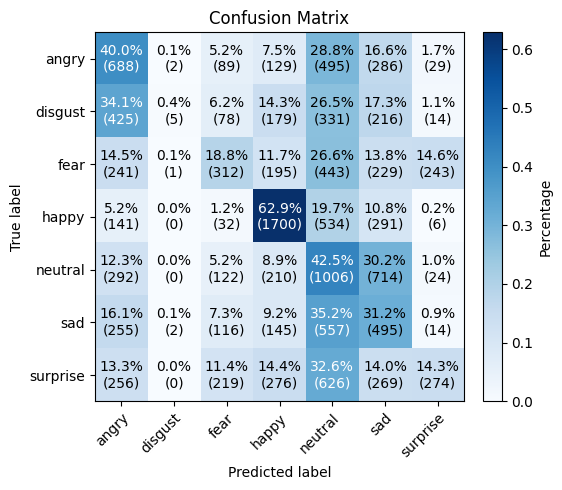

In [23]:
## AN
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)